In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer

from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()
'''disini fungsi describe secara otomatis akan deteksi fitur mana yang merupakan integer'''

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<function matplotlib.pyplot.show(close=None, block=None)>

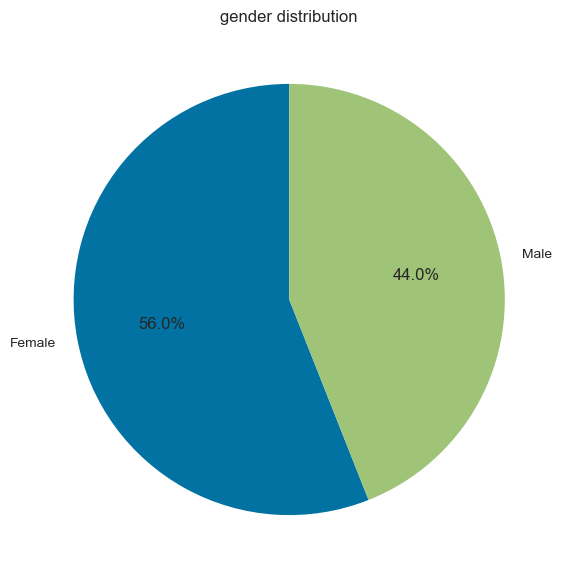

In [9]:
plt.figure(figsize=[10,7])
plt.pie(df['Gender'].value_counts(), labels=["Female","Male"], autopct='%1.1f%%',startangle=90)
plt.title("gender distribution")
plt.show

# Analisis Distribusi Demografi

Setelah melakukan analisis pada variabel gender, ditemukan bahwa distribusi didominasi oleh **Perempuan (56%)**. Untuk memperdalam pemahaman terhadap karakteristik audiens, langkah selanjutnya adalah menganalisis variabel usia.

## Pengelompokan Usia (Data Binning)

Untuk memudahkan interpretasi data yang bersifat kontinu, kita akan menerapkan metode **Binning**. Metode ini dilakukan dengan membagi rentang usia responden ke dalam beberapa interval (bin) tertentu.

### Mengapa Menggunakan Binning?
* **Menyederhanakan Data:** Mengubah angka usia yang bervariasi menjadi kategori yang lebih mudah dikelola.
* **Identifikasi Tren:** Memudahkan pencarian kelompok usia potensial atau segmen pasar tertentu.
* **Optimalisasi Visualisasi:** Menghasilkan grafik (seperti *Bar Chart*) yang lebih bersih dan informatif.

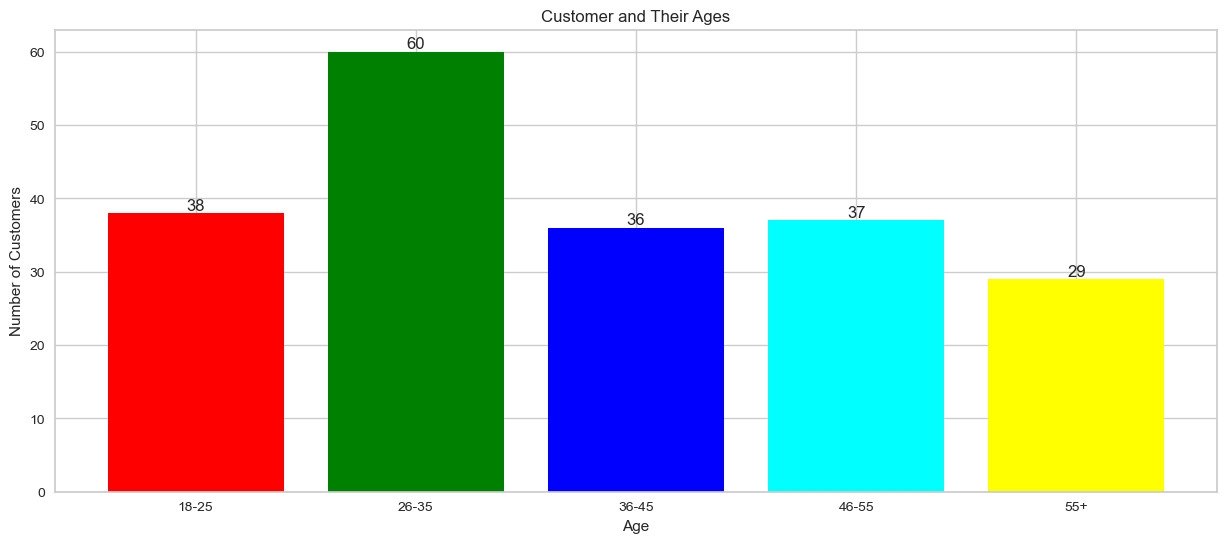

In [ ]:
age18_25 = df.Age[(df.Age >= 18) & (df.Age <= 25)]
age26_35 = df.Age[(df.Age >= 26) & (df.Age <= 35)]
age36_45 = df.Age[(df.Age >= 36) & (df.Age <= 45)]
age46_55 = df.Age[(df.Age >= 46) & (df.Age <= 55)]
age55above = df.Age[df.Age >= 56]

# Menyusun data untuk plotting
x = ["18-25", "26-35", "36-45", "46-55", "55+"]
y = [len(age18_25.values), len(age26_35.values), len(age36_45.values), len(age46_55.values), len(age55above.values)]
 
# Membuat bar chart untuk distribusi usia pelanggan
plt.figure(figsize=(15, 6))
plt.bar(x, y, color=['red', 'green', 'blue', 'cyan', 'yellow'])
plt.title("Customer and Their Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
 
# Menambahkan label jumlah pelanggan di atas setiap bar
for i in range(len(x)):
  plt.text(i, y[i], y[i], ha='center', va='bottom')
  '''text = memberikan teks di koordinat tertentu
      i = koordinat horizontal
       y[i] yang pertama = koordinat vertikal
       y[i] yang kedua = apa yang mau kita tulis di koordinat itu
       ha=center agar tulisan tepat di tengah
       va=bottom agar teks tepat berada di atas batang bukan masuk kedalam batang'''
 
plt.show()

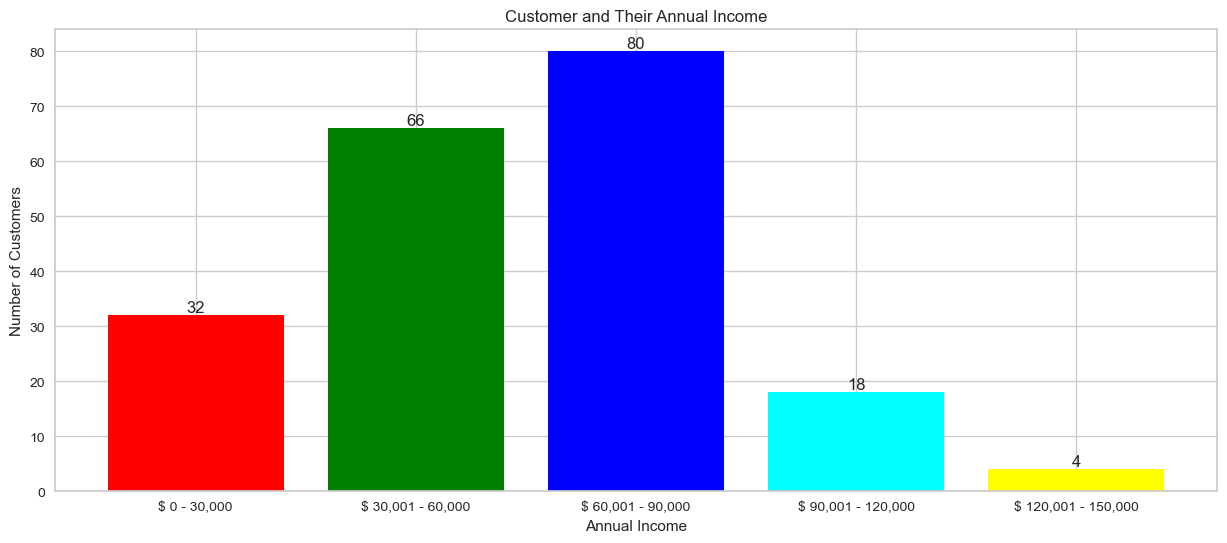

In [15]:
# Mengelompokkan pendapatan tahunan pelanggan ke dalam kategori dan menghitung jumlah pelanggan di setiap kategori
ai0_30 = df["Annual Income (k$)"][(df["Annual Income (k$)"] >= 0) & (df["Annual Income (k$)"] <= 30)]
ai31_60 = df["Annual Income (k$)"][(df["Annual Income (k$)"] >= 31) & (df["Annual Income (k$)"] <= 60)]
ai61_90 = df["Annual Income (k$)"][(df["Annual Income (k$)"] >= 61) & (df["Annual Income (k$)"] <= 90)]
ai91_120 = df["Annual Income (k$)"][(df["Annual Income (k$)"] >= 91) & (df["Annual Income (k$)"] <= 120)]
ai121_150 = df["Annual Income (k$)"][(df["Annual Income (k$)"] >= 121) & (df["Annual Income (k$)"] <= 150)]
 
# Menyusun data untuk plotting
aix = ["$ 0 - 30,000", "$ 30,001 - 60,000", "$ 60,001 - 90,000", "$ 90,001 - 120,000", "$ 120,001 - 150,000"]
aiy = [len(ai0_30.values), len(ai31_60.values), len(ai61_90.values), len(ai91_120.values), len(ai121_150.values)]
 
# Membuat bar chart untuk distribusi pendapatan tahunan pelanggan
plt.figure(figsize=(15, 6))
plt.bar(aix, aiy, color=['red', 'green', 'blue', 'cyan', 'yellow'])
plt.title("Customer and Their Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)  # Memutar label sumbu x agar lebih mudah dibaca
 
# Menambahkan label jumlah pelanggan di atas setiap bar
for i in range(len(aix)):
  plt.text(i, aiy[i], aiy[i], ha='center', va='bottom')
 
plt.show()

In [27]:
#mengambil kolom tertentu untuk dianalisa lebih lanjut.
X=df.iloc[:,[3,4]].values #mengambil seluruh baris (:),mengambil kolom 3 dan 4 ([3,4])

df_analisis = pd.DataFrame(X,columns=['Annual Income','Spending Score'])
# big = df_analisis["Annual Income"]>19
# print(df_analisis[big])

c:\Anaconda\envs\scit_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\envs\scit_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\envs\scit_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\envs\scit_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

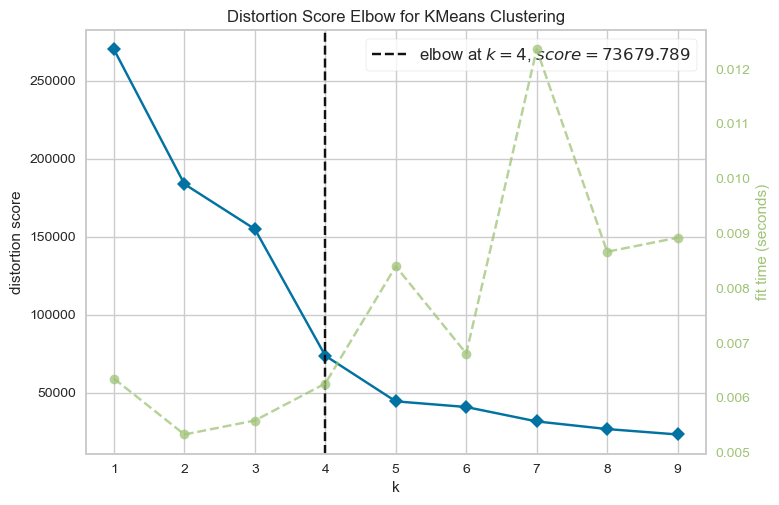

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [29]:
kmeans = KMeans()

visualizer = KElbowVisualizer(kmeans,k=(1,10))

visualizer.fit(X)

visualizer.show()

In [ ]:
kmeans = KMeans(n_clusters=4,random_state=0)
kmeans.fit(X)

labels = kmeans.labels_ 
'''secara atribut,kmeans.fit menghasilkan kolom label yang berisi setiap baris masuk di cluster berapa'''
k = 4

def analyze(X,labels,k):
    print("analisis hasil clustering") 
    for cluster_id in range(k):
        cluster_data = X[labels == cluster_id] 
        '''cluster data hanya berisi nilai yang sama dengan looping cluster_id,caranya dengan indexing dari X
        intinya disini kita membuat variabel baru yang menyimpan hasil agar bisa dianalisis'''
        
        mean_income = cluster_data[:,0].mean() #ambil seluruh baris dari kolom 0
        mean_spending = cluster_data[:,1].mean() #ambil seluruh baris dari kolom 1
        
        print(f"\n Cluster id {cluster_id+1}: ")
        print(f'rata-rata annual income : {mean_income :.2f}')
        print(f'rata-rata spending score : {mean_spending :.2f}')
        
analyze(X,labels,k)

analisis hasil clustering

 Cluster id 1: 
rata-rata annual income : 48.26
rata-rata spending score : 56.48

 Cluster id 2: 
rata-rata annual income : 86.54
rata-rata spending score : 82.13

 Cluster id 3: 
rata-rata annual income : 87.00
rata-rata spending score : 18.63

 Cluster id 4: 
rata-rata annual income : 26.30
rata-rata spending score : 20.91


c:\Anaconda\envs\scit_ai\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\anggraini wijayanti\AppData\Local\Temp\ipykernel_12772\3262102378.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


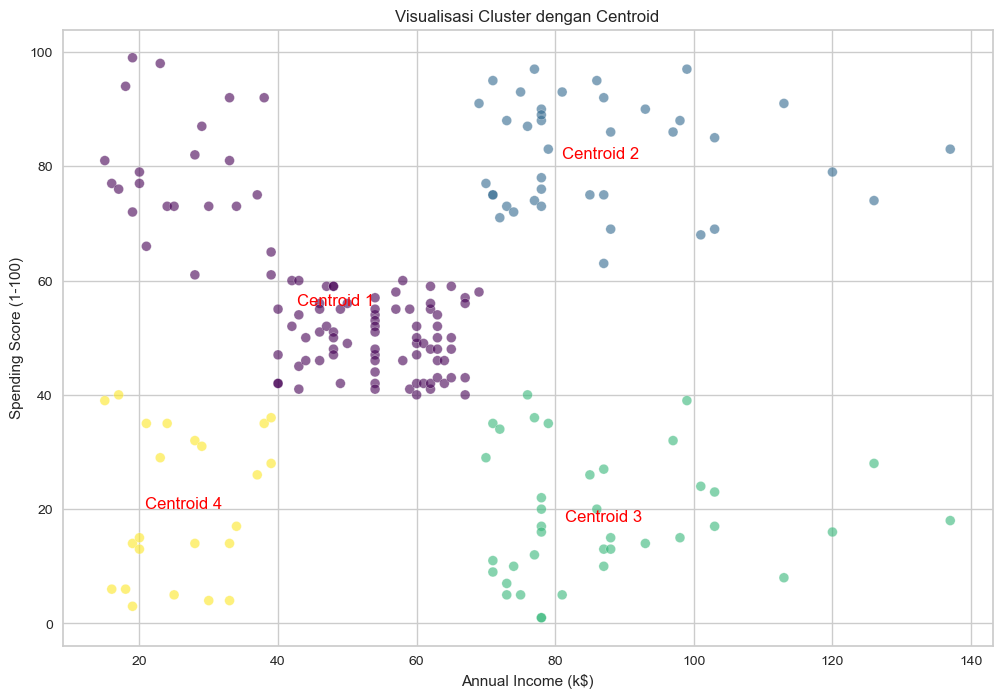

In [ ]:
centroid = kmeans.cluster_centers_

plt.figure(figsize=(12,8))

plt.scatter(X[:,0],X[:,1], c = labels, cmap="viridis", s=50, alpha=0.6,edgecolors='w',marker='o')
'''membuat scatter plot dengan koordinat x nya fitur nol dan y nya fitur 1. parameter c = label untuk mewarnai
titik titik berdasarkan labelnya'''

for i,centroid in enumerate(centroid):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')
    '''centroid berisi 3 kolom = ID,fitur 1,fitur 2, dan 4 baris karena kita ada 4 cluster
        isinya masing masing adalah rata rata dari masing masing fitur di masing masing cluster
        sehingga begitu looping untuk memberi teks dia akan mengambil koordinat di kolom nol dan 1 di 
        setiap loopingnya.'''
 
# Menambahkan judul dan label
plt.title('Visualisasi Cluster dengan Centroid')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
 
plt.show()
